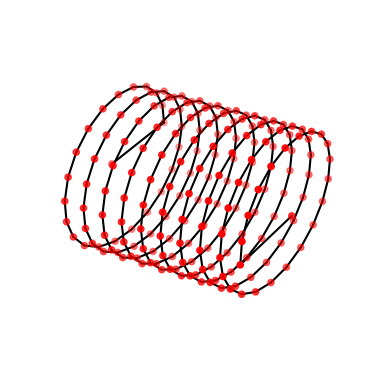

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=920,
                            youngs_rod=1e9,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=True,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')

forces_to_apply = [np.array([1000.0, 0.0, 0.0])]

# env.add_force('gravity', g=np.array([10, 0.0, 0.0]))
env.add_force('pointForces', point_force_node_indices=[geo.nodes.shape[0]-1], 
              point_force_vectors=forces_to_apply)
env.add_force('damping', eta=100)
# env.add_force('selfContact', delta=5e-4, h=0.0016, kc=1)

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0]) # fix the first node
robot = robot.fix_nodes(fixed_points)
end_force = []
factors = []
def change_pointForces(robot, t):
    #slowly increase the point force over time
    factor = min(t/robot.sim_params.total_time, 1.0)
    robot.env.point_force_vectors = [factor * forces_to_apply[i] for i in range(len(forces_to_apply))]
    
    end_force.append(robot.env.point_force_vectors[0].copy())
    factors.append(factor)
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = change_pointForces

In [3]:
robots, t_arr, f_norms = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)

end_force.append(forces_to_apply[0]) # add the final force at the end of the simulation
factors.append(1.0) # add the final factor at the end of the simulation

iter: 1, error: 0.000
current_time:  0.01
iter: 1, error: 10.000
iter: 2, error: 4703.304
iter: 3, error: 825.761
iter: 4, error: 14654.744
iter: 5, error: 5222.239
iter: 6, error: 5924.420
iter: 7, error: 206.577
iter: 8, error: 11324.603
iter: 9, error: 2491.958
iter: 10, error: 1644.497
iter: 11, error: 70.257
iter: 12, error: 11244.512
iter: 13, error: 3839.284
iter: 14, error: 949.659
iter: 15, error: 136.659
iter: 16, error: 53.656
iter: 17, error: 34.976
iter: 18, error: 5.998
iter: 19, error: 0.694
current_time:  0.02
iter: 1, error: 11.314
iter: 2, error: 3846.833
iter: 3, error: 263.507
iter: 4, error: 440.577
iter: 5, error: 14.718
iter: 6, error: 8.285
current_time:  0.03
iter: 1, error: 11.485
iter: 2, error: 746.683
iter: 3, error: 3.328
iter: 4, error: 29.166
current_time:  0.04
iter: 1, error: 11.490
iter: 2, error: 199.548
iter: 3, error: 1.076
iter: 4, error: 0.593
current_time:  0.05
iter: 1, error: 11.822
iter: 2, error: 187.772
iter: 3, error: 0.340
current_time:  

In [4]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

11


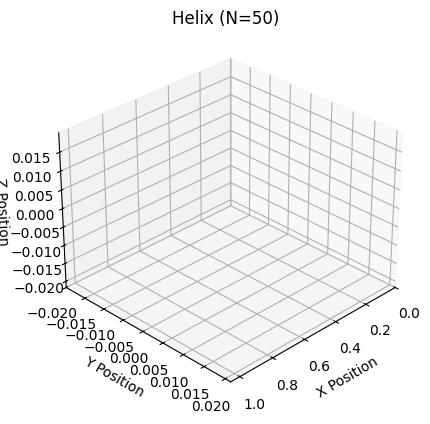

In [5]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky_pulling.gif')

In [6]:
print(end_force)

[array([0., 0., 0.]), array([10.,  0.,  0.]), array([20.,  0.,  0.]), array([30.,  0.,  0.]), array([40.,  0.,  0.]), array([50.,  0.,  0.]), array([60.,  0.,  0.]), array([70.,  0.,  0.]), array([80.,  0.,  0.]), array([90.,  0.,  0.]), array([100.,   0.,   0.]), array([110.,   0.,   0.]), array([120.,   0.,   0.]), array([130.,   0.,   0.]), array([140.,   0.,   0.]), array([150.,   0.,   0.]), array([160.,   0.,   0.]), array([170.,   0.,   0.]), array([180.,   0.,   0.]), array([190.,   0.,   0.]), array([200.,   0.,   0.]), array([210.,   0.,   0.]), array([220.,   0.,   0.]), array([230.,   0.,   0.]), array([240.,   0.,   0.]), array([250.,   0.,   0.]), array([260.,   0.,   0.]), array([270.,   0.,   0.]), array([280.,   0.,   0.]), array([290.,   0.,   0.]), array([300.,   0.,   0.]), array([310.,   0.,   0.]), array([320.,   0.,   0.]), array([330.,   0.,   0.]), array([340.,   0.,   0.]), array([350.,   0.,   0.]), array([360.,   0.,   0.]), array([370.,   0.,   0.]), array(

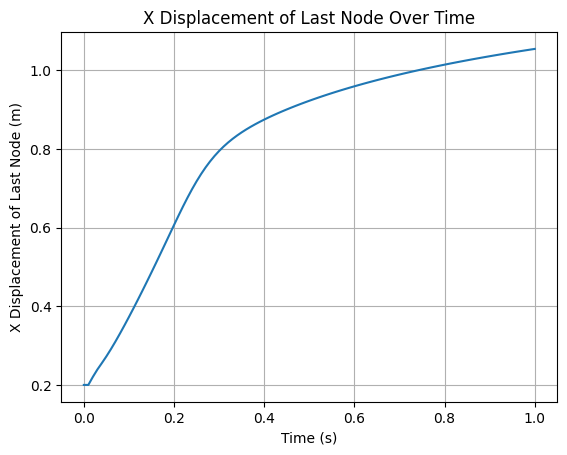

In [7]:
# plot the x discplacement of the last node over time
import matplotlib.pyplot as plt
last_node_x_disp = qs[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.plot(t_arr, last_node_x_disp)
plt.xlabel('Time (s)')
plt.ylabel('X Displacement of Last Node (m)')
plt.title('X Displacement of Last Node Over Time')
plt.grid()

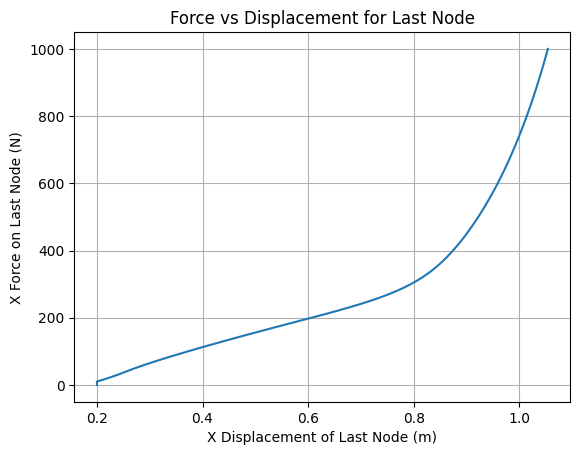

In [8]:
# plot force vs displacement for the last node
plt.figure()
plt.plot(last_node_x_disp, np.array(end_force)[:, 0]) # x component of the force
plt.xlabel('X Displacement of Last Node (m)')
plt.ylabel('X Force on Last Node (N)')
plt.title('Force vs Displacement for Last Node')
plt.grid()
plt.show()

In [9]:
# get training data for HoDEL
T = qs.shape[0]

qs_nodes = qs[:, :robot.n_nodes * 3]
first_x = qs_nodes[:, 0]
last_x  = qs_nodes[:, 3*(robot.n_nodes-1)]

qs_data = np.stack([first_x, last_x], axis=1)

lambda_vals = np.array(factors).squeeze() # shape (T,)
train_data = {
    "lambdas": lambda_vals,   # shape (T,)
    "qs": qs_data                  # shape (T, 2)
}

# print(qs_data.shape)
# print(lambda_vals.shape)
# print(qs_data)

np.savez("slinky_data_1D.npz", **train_data)



In [10]:
from dismech.logging import logDataForRendering
t_arr=t_arr[::10] # sampled time_array
qs = qs[::10]  # sampled qs
rod_data, shell_data = logDataForRendering(qs, t_arr.reshape(-1, 1), robot, len(t_arr), False, robot.map_node_to_dof)

from dismech.logging import export_rod_shell_data
export_rod_shell_data(robot, rod_file='rawDataRod.txt', shell_file='rawDataShell.txt',
                          rod_js='rodData_slinky1D.js', shell_js='shellData.js',
                          rod_radius=0.1, scaleFactor=60)

(11, 808) (11, 1) (11, 807)
(0,)
0


/Users/radha/GitRepos/dismech-python/src/dismech/logging.py:100: UserWarning:

loadtxt: input contained no data: "rawDataShell.txt"



In [11]:
# full centerline
q_centerline = np.hstack([qs_nodes[:, 0:3], qs_nodes[:, 3*(robot.n_nodes-1):3*robot.n_nodes]])
print(q_centerline.shape)
print(q_centerline[::10,:].shape)
centerline_data = {"qs": q_centerline[::10,:]} # shape (T/10, 6)
np.savez("slinky_1D_centerline.npz", **centerline_data)

(101, 6)
(11, 6)
